##Model 1: Transformer (DEIT)
This code file implements a binary image classification pipeline using a transformer model (DeiT) to classify images as silver or non-silver. It loads images from Google Drive, balances the dataset by sampling equal classes, and splits the data into training, validation, and test sets. A custom dataset class handles image loading, preprocessing, and light augmentation. The model is fine-tuned using Hugging Face’s Trainer with early stopping and evaluated using accuracy, precision, recall, and F1 score. The model is tested, and performance is analyzed using a confusion matrix and classification report, with additional threshold tuning applied to optimize F1 score.

In [17]:
# =========================
# Install
# =========================
!pip install -q transformers accelerate evaluate pillow scikit-learn

# =========================
# Imports
# =========================
import os
import random
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset

from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

from transformers import (
    AutoImageProcessor,
    ViTForImageClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# =========================
# Google Drive
# =========================
drive.mount("/content/drive")

# =========================
# Paths
# =========================
silver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/silver_images"
nonsilver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/non_silver_images"

SEED = 42
VAL_SPLIT = 0.2
TEST_SPLIT = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# =========================
# Checkpoint
# IMPORTANT:
# For this checkpoint, use ViTForImageClassification.
# =========================
CHECKPOINT = "facebook/deit-small-patch16-224"

# =========================
# Processor + model
# =========================
image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT)

model = ViTForImageClassification.from_pretrained(
    CHECKPOINT,
    num_labels=2,
    id2label={0: "non_silver", 1: "silver"},
    label2id={"non_silver": 0, "silver": 1},
    ignore_mismatched_sizes=True,  # only classifier head should be resized
)

# =========================
# File lists
# =========================
silver_files = [
    f for f in os.listdir(silver_dir)
    if os.path.isfile(os.path.join(silver_dir, f))
]

nonsilver_files = [
    f for f in os.listdir(nonsilver_dir)
    if os.path.isfile(os.path.join(nonsilver_dir, f))
]

print("Silver files:", len(silver_files))
print("Non-silver files:", len(nonsilver_files))

# =========================
# Sample equal non-silver
# =========================
sampled_nonsilver_files = random.sample(nonsilver_files, len(silver_files))

silver_paths = [os.path.join(silver_dir, f) for f in silver_files]
nonsilver_paths = [os.path.join(nonsilver_dir, f) for f in sampled_nonsilver_files]

random.shuffle(silver_paths)
random.shuffle(nonsilver_paths)

# =========================
# Split each class separately
# =========================
n_per_class = len(silver_paths)

test_count = int(n_per_class * TEST_SPLIT)
val_count = int(n_per_class * VAL_SPLIT)

silver_test = silver_paths[:test_count]
silver_val = silver_paths[test_count:test_count + val_count]
silver_train = silver_paths[test_count + val_count:]

nonsilver_test = nonsilver_paths[:test_count]
nonsilver_val = nonsilver_paths[test_count:test_count + val_count]
nonsilver_train = nonsilver_paths[test_count + val_count:]

# =========================
# Combine splits
# =========================
train_paths = silver_train + nonsilver_train
train_labels = [1] * len(silver_train) + [0] * len(nonsilver_train)

val_paths = silver_val + nonsilver_val
val_labels = [1] * len(silver_val) + [0] * len(nonsilver_val)

test_paths = silver_test + nonsilver_test
test_labels = [1] * len(silver_test) + [0] * len(nonsilver_test)

# =========================
# Shuffle within each split
# =========================
train_combined = list(zip(train_paths, train_labels))
val_combined = list(zip(val_paths, val_labels))
test_combined = list(zip(test_paths, test_labels))

random.shuffle(train_combined)
random.shuffle(val_combined)
random.shuffle(test_combined)

train_paths, train_labels = zip(*train_combined)
val_paths, val_labels = zip(*val_combined)
test_paths, test_labels = zip(*test_combined)

train_paths, train_labels = list(train_paths), list(train_labels)
val_paths, val_labels = list(val_paths), list(val_labels)
test_paths, test_labels = list(test_paths), list(test_labels)

print("Train size:", len(train_paths))
print("Val size:", len(val_paths))
print("Test size:", len(test_paths))

# =========================
# Dataset
# =========================
class SilverDataset(Dataset):
    def __init__(self, paths, labels, processor, train=False):
        self.paths = paths
        self.labels = labels
        self.processor = processor
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        image = Image.open(path).convert("RGB")

        # light augmentation for training
        if self.train:
            if random.random() > 0.5:
                image = image.transpose(Image.FLIP_LEFT_RIGHT)

        encoded = self.processor(images=image, return_tensors="pt")

        return {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

train_ds = SilverDataset(train_paths, train_labels, image_processor, train=True)
val_ds = SilverDataset(val_paths, val_labels, image_processor, train=False)
test_ds = SilverDataset(test_paths, test_labels, image_processor, train=False)

# =========================
# Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    p = precision_score(labels, preds, zero_division=0)
    r = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    return {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
    }

# =========================
# Training arguments
# =========================
training_args = TrainingArguments(
    output_dir="./deit_silver_output",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

# =========================
# Trainer
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# =========================
# Train
# =========================
trainer.train()

# =========================
# Validation results
# =========================
val_results = trainer.evaluate()
print("\nValidation Results:")
for k, v in val_results.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# =========================
# Test prediction
# =========================
pred_output = trainer.predict(test_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# =========================
# Classification report at threshold 0.5
# =========================
y_pred = (probs > 0.5).astype(int)

print("\nConfusion Matrix (threshold = 0.50):")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report (threshold = 0.50):")
print(classification_report(y_true, y_pred, digits=4))

# =========================
# Threshold tuning
# =========================
best_t, best_f1 = 0.5, 0.0


for t in np.arange(0.20, 0.70, 0.01):
    preds = (probs > t).astype(int)

    f1 = f1_score(y_true, preds, zero_division=0)
    p = precision_score(y_true, preds, zero_division=0)
    r = recall_score(y_true, preds, zero_division=0)

    print(f"t={t:.4f} | F1={f1:.4f} | P={p:.4f} | R={r:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest threshold: {best_t:.4f} | Best F1: {best_f1:.4f}")

y_pred_best = (probs > best_t).astype(int)

print("\nConfusion Matrix (best threshold):")
print(confusion_matrix(y_true, y_pred_best))

print("\nClassification Report (best threshold):")
print(classification_report(y_true, y_pred_best, digits=4))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: facebook/deit-small-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Silver files: 3655
Non-silver files: 16129
Train size: 5118
Val size: 1462
Test size: 730


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Validation Results:
eval_loss: 0.4791
eval_accuracy: 0.8461
eval_precision: 0.8260
eval_recall: 0.8769
eval_f1: 0.8507
eval_runtime: 18.7926
eval_samples_per_second: 77.7970
eval_steps_per_second: 4.8960
epoch: 6.0000

Confusion Matrix (threshold = 0.50):
[[305  60]
 [ 35 330]]

Classification Report (threshold = 0.50):
              precision    recall  f1-score   support

           0     0.8971    0.8356    0.8652       365
           1     0.8462    0.9041    0.8742       365

    accuracy                         0.8699       730
   macro avg     0.8716    0.8699    0.8697       730
weighted avg     0.8716    0.8699    0.8697       730

t=0.2000 | F1=0.8632 | P=0.7963 | R=0.9425
t=0.2100 | F1=0.8647 | P=0.8028 | R=0.9370
t=0.2200 | F1=0.8655 | P=0.8061 | R=0.9342
t=0.2300 | F1=0.8655 | P=0.8061 | R=0.9342
t=0.2400 | F1=0.8677 | P=0.8100 | R=0.9342
t=0.2500 | F1=0.8677 | P=0.8100 | R=0.9342
t=0.2600 | F1=0.8673 | P=0.8115 | R=0.9315
t=0.2700 | F1=0.8685 | P=0.8134 | R=0.9315
t=0.28

##Model 2: CNN (RESNET-50)
This code file implements a CNN-based image classification pipeline using ResNet-50 to classify images as silver or non-silver.It loads and balances the dataset from Google Drive, splits it into training, validation, and test sets, and uses a custom dataset class for preprocessing and light augmentation. The pretrained ResNet-50 model is fine-tuned using the Hugging Face Trainer with early stopping and evaluated using accuracy, precision, recall, and F1 score.
The model is tested, and performance is analyzed using a confusion matrix and classification report, with additional threshold tuning applied to optimize F1 score.

In [18]:
# =========================
# Install
# =========================
!pip install -q transformers accelerate evaluate pillow scikit-learn timm

# =========================
# Imports
# =========================
import os
import random
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset

from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

from transformers import (
    AutoImageProcessor,
    ResNetForImageClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# =========================
# Google Drive
# =========================
drive.mount("/content/drive")

# =========================
# Paths
# =========================
silver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/silver_images"
nonsilver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/non_silver_images"

SEED = 42
VAL_SPLIT = 0.2
TEST_SPLIT = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# =========================
# Checkpoint
# =========================
CHECKPOINT = "microsoft/resnet-50"

# =========================
# Processor + model
# =========================
image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT, use_fast=True)

model = ResNetForImageClassification.from_pretrained(
    CHECKPOINT,
    num_labels=2,
    id2label={0: "non_silver", 1: "silver"},
    label2id={"non_silver": 0, "silver": 1},
    ignore_mismatched_sizes=True,   # only classifier head is resized
)

# =========================
# File lists
# =========================
silver_files = [
    f for f in os.listdir(silver_dir)
    if os.path.isfile(os.path.join(silver_dir, f))
]

nonsilver_files = [
    f for f in os.listdir(nonsilver_dir)
    if os.path.isfile(os.path.join(nonsilver_dir, f))
]

print("Silver files:", len(silver_files))
print("Non-silver files:", len(nonsilver_files))

# =========================
# Sample equal non-silver
# =========================
sampled_nonsilver_files = random.sample(nonsilver_files, len(silver_files))

silver_paths = [os.path.join(silver_dir, f) for f in silver_files]
nonsilver_paths = [os.path.join(nonsilver_dir, f) for f in sampled_nonsilver_files]

random.shuffle(silver_paths)
random.shuffle(nonsilver_paths)

# =========================
# Split each class separately
# =========================
n_per_class = len(silver_paths)

test_count = int(n_per_class * TEST_SPLIT)
val_count = int(n_per_class * VAL_SPLIT)

silver_test = silver_paths[:test_count]
silver_val = silver_paths[test_count:test_count + val_count]
silver_train = silver_paths[test_count + val_count:]

nonsilver_test = nonsilver_paths[:test_count]
nonsilver_val = nonsilver_paths[test_count:test_count + val_count]
nonsilver_train = nonsilver_paths[test_count + val_count:]

# =========================
# Combine splits
# =========================
train_paths = silver_train + nonsilver_train
train_labels = [1] * len(silver_train) + [0] * len(nonsilver_train)

val_paths = silver_val + nonsilver_val
val_labels = [1] * len(silver_val) + [0] * len(nonsilver_val)

test_paths = silver_test + nonsilver_test
test_labels = [1] * len(silver_test) + [0] * len(nonsilver_test)

# =========================
# Shuffle within each split
# =========================
train_combined = list(zip(train_paths, train_labels))
val_combined = list(zip(val_paths, val_labels))
test_combined = list(zip(test_paths, test_labels))

random.shuffle(train_combined)
random.shuffle(val_combined)
random.shuffle(test_combined)

train_paths, train_labels = zip(*train_combined)
val_paths, val_labels = zip(*val_combined)
test_paths, test_labels = zip(*test_combined)

train_paths, train_labels = list(train_paths), list(train_labels)
val_paths, val_labels = list(val_paths), list(val_labels)
test_paths, test_labels = list(test_paths), list(test_labels)

print("Train size:", len(train_paths))
print("Val size:", len(val_paths))
print("Test size:", len(test_paths))

# =========================
# Dataset
# =========================
class SilverDataset(Dataset):
    def __init__(self, paths, labels, processor, train=False):
        self.paths = paths
        self.labels = labels
        self.processor = processor
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        image = Image.open(path).convert("RGB")

        # light augmentation for training
        if self.train:
            if random.random() > 0.5:
                image = image.transpose(Image.FLIP_LEFT_RIGHT)

        encoded = self.processor(images=image, return_tensors="pt")

        return {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

train_ds = SilverDataset(train_paths, train_labels, image_processor, train=True)
val_ds = SilverDataset(val_paths, val_labels, image_processor, train=False)
test_ds = SilverDataset(test_paths, test_labels, image_processor, train=False)

# =========================
# Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    p = precision_score(labels, preds, zero_division=0)
    r = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    return {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
    }

# =========================
# Training arguments
# =========================
training_args = TrainingArguments(
    output_dir="./resnet_silver_output",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=160,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

# =========================
# Trainer
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# =========================
# Train
# =========================
trainer.train()

# =========================
# Validation results
# =========================
val_results = trainer.evaluate()
print("\nValidation Results:")
for k, v in val_results.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# =========================
# Test prediction
# =========================
pred_output = trainer.predict(test_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# =========================
# Classification report at threshold 0.5
# =========================
y_pred = (probs > 0.5).astype(int)

print("\nConfusion Matrix (threshold = 0.50):")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report (threshold = 0.50):")
print(classification_report(y_true, y_pred, digits=4))

# =========================
# Threshold tuning
# =========================
best_t, best_f1 = 0.5, f1_score(y_true, y_pred, average="macro", zero_division=0)


for t in np.arange(0.20, 0.70, 0.01):
    preds = (probs > t).astype(int)

    f1 = f1_score(y_true, preds, average="macro", zero_division=0)
    p = precision_score(y_true, preds, zero_division=0)
    r = recall_score(y_true, preds, zero_division=0)

    print(f"t={t:.4f} | F1={f1:.4f} | P={p:.4f} | R={r:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest threshold: {best_t:.4f} | Best F1: {best_f1:.4f}")

y_pred_best = (probs > best_t).astype(int)

print("\nConfusion Matrix (best threshold):")
print(confusion_matrix(y_true, y_pred_best))

print("\nClassification Report (best threshold):")
print(classification_report(y_true, y_pred_best, digits=4))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                          
--------------------+----------+------------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([2, 2048])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Silver files: 3655
Non-silver files: 16129
Train size: 5118
Val size: 1462
Test size: 730


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.663434,0.599460,0.744870,0.768769,0.700410,0.732999
2,0.491063,0.429764,0.795486,0.799169,0.789330,0.794219
3,0.371527,0.382232,0.828317,0.825203,0.833105,0.829135
4,0.300919,0.368267,0.836525,0.851429,0.815321,0.832984
5,0.247007,0.359315,0.839261,0.834232,0.846785,0.840462
6,0.214068,0.355449,0.846101,0.849448,0.841313,0.845361
7,0.193944,0.362366,0.848153,0.845319,0.852257,0.848774
8,0.171238,0.367487,0.844733,0.848066,0.839945,0.843986
9,0.153333,0.366398,0.854993,0.856946,0.852257,0.854595
10,0.141826,0.371628,0.847469,0.846995,0.848153,0.847573


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Validation Results:
eval_loss: 0.3664
eval_accuracy: 0.8550
eval_precision: 0.8569
eval_recall: 0.8523
eval_f1: 0.8546
eval_runtime: 16.3519
eval_samples_per_second: 89.4080
eval_steps_per_second: 2.8130
epoch: 10.0000

Confusion Matrix (threshold = 0.50):
[[318  47]
 [ 61 304]]

Classification Report (threshold = 0.50):
              precision    recall  f1-score   support

           0     0.8391    0.8712    0.8548       365
           1     0.8661    0.8329    0.8492       365

    accuracy                         0.8521       730
   macro avg     0.8526    0.8521    0.8520       730
weighted avg     0.8526    0.8521    0.8520       730

t=0.2000 | F1=0.8298 | P=0.7687 | R=0.9014
t=0.2100 | F1=0.8264 | P=0.7689 | R=0.8932
t=0.2200 | F1=0.8264 | P=0.7689 | R=0.8932
t=0.2300 | F1=0.8240 | P=0.7709 | R=0.8849
t=0.2400 | F1=0.8314 | P=0.7840 | R=0.8849
t=0.2500 | F1=0.8335 | P=0.7878 | R=0.8849
t=0.2600 | F1=0.8331 | P=0.7892 | R=0.8822
t=0.2700 | F1=0.8353 | P=0.7931 | R=0.8822
t=0.2

##Model 3: CNN (DenseNet-121)
This code file implements a DenseNet-based image classification pipeline to classify images as silver or non-silver. It loads and balances the dataset, splits it into training, validation, and test sets, and uses a custom dataset class for preprocessing and light augmentation. A pretrained DenseNet-121 model is fine-tuned using the Hugging Face Trainer with early stopping and evaluated using accuracy, precision, recall, and F1 score. The model is tested, and performance is analyzed using a confusion matrix and classification report, with additional threshold tuning applied to optimize F1 score.

In [1]:
# =========================
# Install
# =========================
!pip install -q transformers accelerate evaluate pillow scikit-learn timm

# =========================
# Imports
# =========================
import os
import random
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset

from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# =========================
# Google Drive
# =========================
drive.mount("/content/drive")

# =========================
# Paths
# =========================
silver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/silver_images"
nonsilver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/non_silver_images"

SEED = 42
VAL_SPLIT = 0.2
TEST_SPLIT = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# =========================
# Checkpoint
# =========================
CHECKPOINT = "timm/densenet121.tv_in1k"

# =========================
# Processor + model
# =========================
image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT, use_fast=True)

model = AutoModelForImageClassification.from_pretrained(
    CHECKPOINT,
    num_labels=2,
    id2label={0: "non_silver", 1: "silver"},
    label2id={"non_silver": 0, "silver": 1},
    ignore_mismatched_sizes=True,   # only classifier head is resized
)

# =========================
# File lists
# =========================
silver_files = [
    f for f in os.listdir(silver_dir)
    if os.path.isfile(os.path.join(silver_dir, f))
]

nonsilver_files = [
    f for f in os.listdir(nonsilver_dir)
    if os.path.isfile(os.path.join(nonsilver_dir, f))
]

print("Silver files:", len(silver_files))
print("Non-silver files:", len(nonsilver_files))

# =========================
# Sample equal non-silver
# =========================
sampled_nonsilver_files = random.sample(nonsilver_files, len(silver_files))

silver_paths = [os.path.join(silver_dir, f) for f in silver_files]
nonsilver_paths = [os.path.join(nonsilver_dir, f) for f in sampled_nonsilver_files]

random.shuffle(silver_paths)
random.shuffle(nonsilver_paths)

# =========================
# Split each class separately
# =========================
n_per_class = len(silver_paths)

test_count = int(n_per_class * TEST_SPLIT)
val_count = int(n_per_class * VAL_SPLIT)

silver_test = silver_paths[:test_count]
silver_val = silver_paths[test_count:test_count + val_count]
silver_train = silver_paths[test_count + val_count:]

nonsilver_test = nonsilver_paths[:test_count]
nonsilver_val = nonsilver_paths[test_count:test_count + val_count]
nonsilver_train = nonsilver_paths[test_count + val_count:]

# =========================
# Combine splits
# =========================
train_paths = silver_train + nonsilver_train
train_labels = [1] * len(silver_train) + [0] * len(nonsilver_train)

val_paths = silver_val + nonsilver_val
val_labels = [1] * len(silver_val) + [0] * len(nonsilver_val)

test_paths = silver_test + nonsilver_test
test_labels = [1] * len(silver_test) + [0] * len(nonsilver_test)

# =========================
# Shuffle within each split
# =========================
train_combined = list(zip(train_paths, train_labels))
val_combined = list(zip(val_paths, val_labels))
test_combined = list(zip(test_paths, test_labels))

random.shuffle(train_combined)
random.shuffle(val_combined)
random.shuffle(test_combined)

train_paths, train_labels = zip(*train_combined)
val_paths, val_labels = zip(*val_combined)
test_paths, test_labels = zip(*test_combined)

train_paths, train_labels = list(train_paths), list(train_labels)
val_paths, val_labels = list(val_paths), list(val_labels)
test_paths, test_labels = list(test_paths), list(test_labels)

print("Train size:", len(train_paths))
print("Val size:", len(val_paths))
print("Test size:", len(test_paths))

# =========================
# Dataset
# =========================
class SilverDataset(Dataset):
    def __init__(self, paths, labels, processor, train=False):
        self.paths = paths
        self.labels = labels
        self.processor = processor
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        image = Image.open(path).convert("RGB")

        # light augmentation for training
        if self.train:
            if random.random() > 0.5:
                image = image.transpose(Image.FLIP_LEFT_RIGHT)

        encoded = self.processor(images=image, return_tensors="pt")

        return {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

train_ds = SilverDataset(train_paths, train_labels, image_processor, train=True)
val_ds = SilverDataset(val_paths, val_labels, image_processor, train=False)
test_ds = SilverDataset(test_paths, test_labels, image_processor, train=False)

# =========================
# Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    p = precision_score(labels, preds, zero_division=0)
    r = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    return {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
    }

# =========================
# Training arguments
# =========================
training_args = TrainingArguments(
    output_dir="./densenet_silver_output",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=160,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

# =========================
# Trainer
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# =========================
# Train
# =========================
trainer.train()

# =========================
# Validation results
# =========================
val_results = trainer.evaluate()
print("\nValidation Results:")
for k, v in val_results.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# =========================
# Test prediction
# =========================
pred_output = trainer.predict(test_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# =========================
# Classification report at threshold 0.5
# =========================
y_pred = (probs > 0.5).astype(int)

print("\nConfusion Matrix (threshold = 0.50):")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report (threshold = 0.50):")
print(classification_report(y_true, y_pred, digits=4))

# =========================
# Threshold tuning
# =========================
best_t, best_f1 = 0.5, f1_score(y_true, y_pred, average="macro", zero_division=0)


for t in np.arange(0.20, 0.70, 0.01):
    preds = (probs > t).astype(int)

    f1 = f1_score(y_true, preds, average="macro", zero_division=0)
    p = precision_score(y_true, preds, zero_division=0)
    r = recall_score(y_true, preds, zero_division=0)

    print(f"t={t:.4f} | F1={f1:.4f} | P={p:.4f} | R={r:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest threshold: {best_t:.4f} | Best F1: {best_f1:.4f}")

y_pred_best = (probs > best_t).astype(int)

print("\nConfusion Matrix (best threshold):")
print(confusion_matrix(y_true, y_pred_best))

print("\nClassification Report (best threshold):")
print(classification_report(y_true, y_pred_best, digits=4))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


MessageError: Error: credential propagation was unsuccessful

##Model 4: CNN (EfficientNet-B0)
This code file implements a binary image classification pipeline using a convolutional neural network (EfficientNet-B0) to classify images as silver or non-silver. It loads images from Google Drive, balances the dataset by sampling equal classes, and splits the data into training, validation, and test sets. A custom dataset class handles image loading, preprocessing, and light augmentation. The pretrained EfficientNet-B0 model is fine-tuned using Hugging Face’s Trainer with early stopping and evaluated using accuracy, precision, recall, and F1 score. The model is tested, and performance is analyzed using a confusion matrix and classification report, with additional threshold tuning applied to optimize F1 score.\

In [ ]:
# =========================
# Install
# =========================
!pip install -q transformers accelerate evaluate pillow scikit-learn timm

# =========================
# Imports
# =========================
import os
import random
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset

from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# =========================
# Google Drive
# =========================
drive.mount("/content/drive")

# =========================
# Paths
# =========================
silver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/silver_images"
nonsilver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/non_silver_images"

SEED = 42
VAL_SPLIT = 0.2
TEST_SPLIT = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# =========================
# Checkpoint
# =========================
CHECKPOINT = "google/efficientnet-b0"

# =========================
# Processor + model
# =========================
image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT, use_fast=True)

model = AutoModelForImageClassification.from_pretrained(
    CHECKPOINT,
    num_labels=2,
    id2label={0: "non_silver", 1: "silver"},
    label2id={"non_silver": 0, "silver": 1},
    ignore_mismatched_sizes=True,   # only classifier head is resized
)

# =========================
# File lists
# =========================
silver_files = [
    f for f in os.listdir(silver_dir)
    if os.path.isfile(os.path.join(silver_dir, f))
]

nonsilver_files = [
    f for f in os.listdir(nonsilver_dir)
    if os.path.isfile(os.path.join(nonsilver_dir, f))
]

print("Silver files:", len(silver_files))
print("Non-silver files:", len(nonsilver_files))

# =========================
# Sample equal non-silver
# =========================
sampled_nonsilver_files = random.sample(nonsilver_files, len(silver_files))

silver_paths = [os.path.join(silver_dir, f) for f in silver_files]
nonsilver_paths = [os.path.join(nonsilver_dir, f) for f in sampled_nonsilver_files]

random.shuffle(silver_paths)
random.shuffle(nonsilver_paths)

# =========================
# Split each class separately
# =========================
n_per_class = len(silver_paths)

test_count = int(n_per_class * TEST_SPLIT)
val_count = int(n_per_class * VAL_SPLIT)

silver_test = silver_paths[:test_count]
silver_val = silver_paths[test_count:test_count + val_count]
silver_train = silver_paths[test_count + val_count:]

nonsilver_test = nonsilver_paths[:test_count]
nonsilver_val = nonsilver_paths[test_count:test_count + val_count]
nonsilver_train = nonsilver_paths[test_count + val_count:]

# =========================
# Combine splits
# =========================
train_paths = silver_train + nonsilver_train
train_labels = [1] * len(silver_train) + [0] * len(nonsilver_train)

val_paths = silver_val + nonsilver_val
val_labels = [1] * len(silver_val) + [0] * len(nonsilver_val)

test_paths = silver_test + nonsilver_test
test_labels = [1] * len(silver_test) + [0] * len(nonsilver_test)

# =========================
# Shuffle within each split
# =========================
train_combined = list(zip(train_paths, train_labels))
val_combined = list(zip(val_paths, val_labels))
test_combined = list(zip(test_paths, test_labels))

random.shuffle(train_combined)
random.shuffle(val_combined)
random.shuffle(test_combined)

train_paths, train_labels = zip(*train_combined)
val_paths, val_labels = zip(*val_combined)
test_paths, test_labels = zip(*test_combined)

train_paths, train_labels = list(train_paths), list(train_labels)
val_paths, val_labels = list(val_paths), list(val_labels)
test_paths, test_labels = list(test_paths), list(test_labels)

print("Train size:", len(train_paths))
print("Val size:", len(val_paths))
print("Test size:", len(test_paths))

# =========================
# Dataset
# =========================
class SilverDataset(Dataset):
    def __init__(self, paths, labels, processor, train=False):
        self.paths = paths
        self.labels = labels
        self.processor = processor
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        image = Image.open(path).convert("RGB")

        # light augmentation for training
        if self.train:
            if random.random() > 0.5:
                image = image.transpose(Image.FLIP_LEFT_RIGHT)

        encoded = self.processor(images=image, return_tensors="pt")

        return {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

train_ds = SilverDataset(train_paths, train_labels, image_processor, train=True)
val_ds = SilverDataset(val_paths, val_labels, image_processor, train=False)
test_ds = SilverDataset(test_paths, test_labels, image_processor, train=False)

# =========================
# Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    p = precision_score(labels, preds, zero_division=0)
    r = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    return {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
    }

# =========================
# Training arguments
# =========================
training_args = TrainingArguments(
    output_dir="./efficientnet_silver_output",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=160,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

# =========================
# Trainer
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# =========================
# Train
# =========================
trainer.train()

# =========================
# Validation results
# =========================
val_results = trainer.evaluate()
print("\nValidation Results:")
for k, v in val_results.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# =========================
# Test prediction
# =========================
pred_output = trainer.predict(test_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# =========================
# Classification report at threshold 0.5
# =========================
y_pred = (probs > 0.5).astype(int)

print("\nConfusion Matrix (threshold = 0.50):")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report (threshold = 0.50):")
print(classification_report(y_true, y_pred, digits=4))

# =========================
# Threshold tuning
# =========================
best_t, best_f1 = 0.5, 0.0

for t in np.arange(0.20, 0.70, 0.01):
    preds = (probs > t).astype(int)

    f1 = f1_score(y_true, preds)
    p = precision_score(y_true, preds, zero_division=0)
    r = recall_score(y_true, preds, zero_division=0)

    print(f"t={t:.2f} | F1={f1:.2f} | P={p:.2f} | R={r:.2f}")

    if f1 > best_f1 or (f1 == best_f1 and t > best_t):
    #if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest threshold: {best_t:.2f} | Best F1: {best_f1:.2f}")

y_pred_best = (probs > best_t).astype(int)

print("\nConfusion Matrix (best threshold):")
print(confusion_matrix(y_true, y_pred_best))

print("\nClassification Report (best threshold):")
print(classification_report(y_true, y_pred_best, digits=4))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


preprocessor_config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Validation Results:
eval_loss: 0.4799
eval_accuracy: 0.8523
eval_precision: 0.8393
eval_recall: 0.8714
eval_f1: 0.8550
eval_runtime: 12.6234
eval_samples_per_second: 115.8160
eval_steps_per_second: 3.6440
epoch: 9.0000

Confusion Matrix (threshold = 0.50):
[[312  53]
 [ 52 313]]

Classification Report (threshold = 0.50):
              precision    recall  f1-score   support

           0     0.8571    0.8548    0.8560       365
           1     0.8552    0.8575    0.8564       365

    accuracy                         0.8562       730
   macro avg     0.8562    0.8562    0.8562       730
weighted avg     0.8562    0.8562    0.8562       730

t=0.20 | F1=0.86 | P=0.81 | R=0.92
t=0.21 | F1=0.86 | P=0.81 | R=0.92
t=0.22 | F1=0.86 | P=0.82 | R=0.92
t=0.23 | F1=0.86 | P=0.82 | R=0.91
t=0.24 | F1=0.86 | P=0.82 | R=0.91
t=0.25 | F1=0.86 | P=0.82 | R=0.90
t=0.26 | F1=0.86 | P=0.82 | R=0.90
t=0.27 | F1=0.86 | P=0.82 | R=0.90
t=0.28 | F1=0.86 | P=0.82 | R=0.90
t=0.29 | F1=0.86 | P=0.83 | R=0.90

##Model 5: Transformer (ViT Baseline)

This code file implements a binary image classification pipeline using a standard transformer model (Vision Transformer, ViT) to classify images as silver or non-silver. It loads images from Google Drive, balances the dataset by sampling equal classes, and splits the data into training, validation, and test sets. A custom dataset class handles image loading, preprocessing, and light augmentation. The model is fine-tuned using Hugging Face’s Trainer with early stopping and evaluated using accuracy, precision, recall, and F1 score. The model is tested, and performance is analyzed using a confusion matrix and classification report, with additional threshold tuning applied to optimize F1 score.

In [1]:
# =========================
# Install
# =========================
!pip install -q transformers accelerate evaluate pillow scikit-learn timm

# =========================
# Imports
# =========================
import os
import random
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset

from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# =========================
# Google Drive
# =========================
drive.mount("/content/drive")

# =========================
# Paths
# =========================
silver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/silver_images"
nonsilver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/non_silver_images"

SEED = 42
VAL_SPLIT = 0.2
TEST_SPLIT = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# =========================
# Checkpoint
# =========================
CHECKPOINT = "google/vit-base-patch16-224"

# =========================
# Processor + model
# =========================
image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT, use_fast=True)

model = AutoModelForImageClassification.from_pretrained(
    CHECKPOINT,
    num_labels=2,
    id2label={0: "non_silver", 1: "silver"},
    label2id={"non_silver": 0, "silver": 1},
    ignore_mismatched_sizes=True,   # resize classifier head for binary output
)

# =========================
# File lists
# =========================
silver_files = [
    f for f in os.listdir(silver_dir)
    if os.path.isfile(os.path.join(silver_dir, f))
]

nonsilver_files = [
    f for f in os.listdir(nonsilver_dir)
    if os.path.isfile(os.path.join(nonsilver_dir, f))
]

print("Silver files:", len(silver_files))
print("Non-silver files:", len(nonsilver_files))

# =========================
# Sample equal non-silver
# =========================
sampled_nonsilver_files = random.sample(nonsilver_files, len(silver_files))

silver_paths = [os.path.join(silver_dir, f) for f in silver_files]
nonsilver_paths = [os.path.join(nonsilver_dir, f) for f in sampled_nonsilver_files]

random.shuffle(silver_paths)
random.shuffle(nonsilver_paths)

# =========================
# Split each class separately
# =========================
n_per_class = len(silver_paths)

test_count = int(n_per_class * TEST_SPLIT)
val_count = int(n_per_class * VAL_SPLIT)

silver_test = silver_paths[:test_count]
silver_val = silver_paths[test_count:test_count + val_count]
silver_train = silver_paths[test_count + val_count:]

nonsilver_test = nonsilver_paths[:test_count]
nonsilver_val = nonsilver_paths[test_count:test_count + val_count]
nonsilver_train = nonsilver_paths[test_count + val_count:]

# =========================
# Combine splits
# =========================
train_paths = silver_train + nonsilver_train
train_labels = [1] * len(silver_train) + [0] * len(nonsilver_train)

val_paths = silver_val + nonsilver_val
val_labels = [1] * len(silver_val) + [0] * len(nonsilver_val)

test_paths = silver_test + nonsilver_test
test_labels = [1] * len(silver_test) + [0] * len(nonsilver_test)

# =========================
# Shuffle within each split
# =========================
train_combined = list(zip(train_paths, train_labels))
val_combined = list(zip(val_paths, val_labels))
test_combined = list(zip(test_paths, test_labels))

random.shuffle(train_combined)
random.shuffle(val_combined)
random.shuffle(test_combined)

train_paths, train_labels = zip(*train_combined)
val_paths, val_labels = zip(*val_combined)
test_paths, test_labels = zip(*test_combined)

train_paths, train_labels = list(train_paths), list(train_labels)
val_paths, val_labels = list(val_paths), list(val_labels)
test_paths, test_labels = list(test_paths), list(test_labels)

print("Train size:", len(train_paths))
print("Val size:", len(val_paths))
print("Test size:", len(test_paths))

# =========================
# Dataset
# =========================
class SilverDataset(Dataset):
    def __init__(self, paths, labels, processor, train=False):
        self.paths = paths
        self.labels = labels
        self.processor = processor
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        image = Image.open(path).convert("RGB")

        # light augmentation for training
        if self.train:
            if random.random() > 0.5:
                image = image.transpose(Image.FLIP_LEFT_RIGHT)

        encoded = self.processor(images=image, return_tensors="pt")

        return {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

train_ds = SilverDataset(train_paths, train_labels, image_processor, train=True)
val_ds = SilverDataset(val_paths, val_labels, image_processor, train=False)
test_ds = SilverDataset(test_paths, test_labels, image_processor, train=False)

# =========================
# Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    p = precision_score(labels, preds, zero_division=0)
    r = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    return {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
    }

# =========================
# Training arguments
# =========================
training_args = TrainingArguments(
    output_dir="./vit_base_silver_output",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=16,   # lower than EfficientNet because ViT uses more memory
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=160,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

# =========================
# Trainer
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# =========================
# Train
# =========================
trainer.train()

# =========================
# Validation results
# =========================
val_results = trainer.evaluate()
print("\nValidation Results:")
for k, v in val_results.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# =========================
# Test prediction
# =========================
pred_output = trainer.predict(test_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# =========================
# Classification report at threshold 0.5
# =========================
y_pred = (probs > 0.5).astype(int)

print("\nConfusion Matrix (threshold = 0.50):")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report (threshold = 0.50):")
print(classification_report(y_true, y_pred, digits=4))

# =========================
# Threshold tuning
# =========================
best_t, best_f1 = 0.5, 0.0

for t in np.arange(0.20, 0.70, 0.01):
    preds = (probs > t).astype(int)

    f1 = f1_score(y_true, preds, zero_division=0)
    p = precision_score(y_true, preds, zero_division=0)
    r = recall_score(y_true, preds, zero_division=0)

    print(f"t={t:.2f} | F1={f1:.2f} | P={p:.2f} | R={r:.2f}")

    if f1 > best_f1 or (f1 == best_f1 and t > best_t):
    #if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest threshold: {best_t:.2f} | Best F1: {best_f1:.2f}")

y_pred_best = (probs > best_t).astype(int)

print("\nConfusion Matrix (best threshold):")
print(confusion_matrix(y_true, y_pred_best))

print("\nClassification Report (best threshold):")
print(classification_report(y_true, y_pred_best, digits=4))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.0 MB/s eta 0:00:00
Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Validation Results:
eval_loss: 0.7737
eval_accuracy: 0.8755
eval_precision: 0.8685
eval_recall: 0.8851
eval_f1: 0.8767
eval_runtime: 21.7322
eval_samples_per_second: 67.2740
eval_steps_per_second: 4.2330
epoch: 10.0000

Confusion Matrix (threshold = 0.50):
[[326  39]
 [ 46 319]]

Classification Report (threshold = 0.50):
              precision    recall  f1-score   support

           0     0.8763    0.8932    0.8847       365
           1     0.8911    0.8740    0.8824       365

    accuracy                         0.8836       730
   macro avg     0.8837    0.8836    0.8836       730
weighted avg     0.8837    0.8836    0.8836       730

t=0.20 | F1=0.88 | P=0.88 | R=0.89
t=0.21 | F1=0.88 | P=0.88 | R=0.89
t=0.22 | F1=0.88 | P=0.88 | R=0.89
t=0.23 | F1=0.88 | P=0.88 | R=0.89
t=0.24 | F1=0.88 | P=0.88 | R=0.88
t=0.25 | F1=0.88 | P=0.88 | R=0.88
t=0.26 | F1=0.88 | P=0.88 | R=0.88
t=0.27 | F1=0.88 | P=0.88 | R=0.88
t=0.28 | F1=0.88 | P=0.88 | R=0.88
t=0.29 | F1=0.88 | P=0.88 | R=0.88

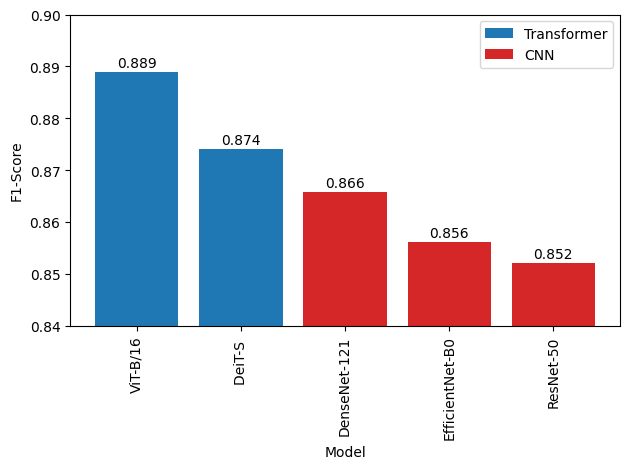

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


plt.rcParams.update({
    "font.size": 10,
    "font.family": "sans-serif"
})

models = ["ViT-B/16", "DeiT-S ", "DenseNet-121", "EfficientNet-B0", "ResNet-50"]
f1_scores = [0.8889, 0.8740, 0.8657, 0.8562, 0.8520]

colors = [
    "#1f77b4", "#1f77b4",  # Transformers
    "#d62728", "#d62728", "#d62728"  # CNNs
]

plt.figure()

plt.bar(models, f1_scores, color=colors)

plt.xlabel("Model")
plt.ylabel("F1-Score")

# (Optional IEEE style: remove title)
# plt.title("Model Comparison Based on F1-Score")

plt.xticks(rotation=90)

# Zoom for clarity
plt.ylim(0.84, 0.90)

# Add values on bars
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center')

legend_elements = [
    Patch(facecolor="#1f77b4", label="Transformer"),
    Patch(facecolor="#d62728", label="CNN")
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

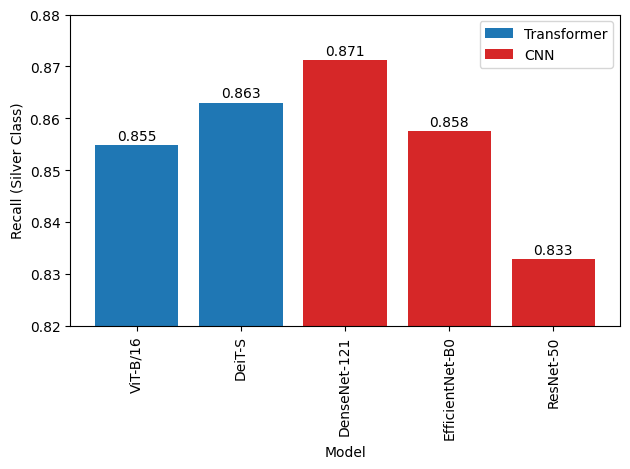

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

models = ["ViT-B/16", "DeiT-S", "DenseNet-121", "EfficientNet-B0", "ResNet-50"]

# Recall for silver class (Class 1)
recall_scores = [0.8548, 0.8630, 0.8712, 0.8575, 0.8329]

# Blue = Transformer, Red = CNN
colors = [
    "#1f77b4", "#1f77b4",
    "#d62728", "#d62728", "#d62728"
]

plt.figure()

plt.bar(models, recall_scores, color=colors)

plt.xlabel("Model")
plt.ylabel("Recall (Silver Class)")

plt.xticks(rotation=90)

# Zoom for clarity
plt.ylim(0.82, 0.88)

# Add values
for i, v in enumerate(recall_scores):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center')

# Legend
legend_elements = [
    Patch(facecolor="#1f77b4", label="Transformer"),
    Patch(facecolor="#d62728", label="CNN")
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("recall_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

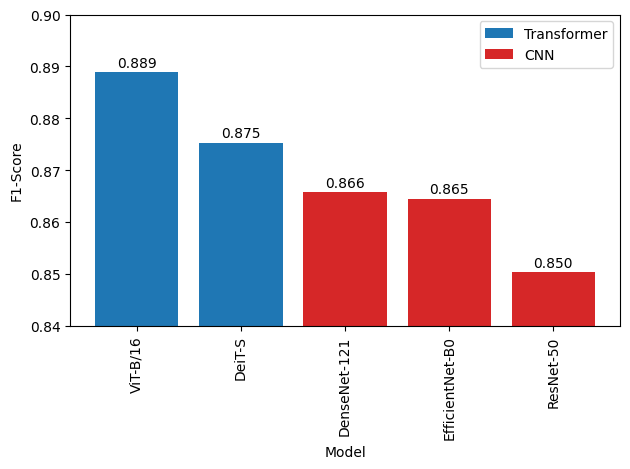

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.size": 10,
    "font.family": "sans-serif"
})

models = ["ViT-B/16", "DeiT-S", "DenseNet-121", "EfficientNet-B0", "ResNet-50"]

# ✅ BEST threshold F1 scores (from your results)
f1_scores = [0.8889, 0.8753, 0.8657, 0.8645, 0.8503]

colors = [
    "#1f77b4", "#1f77b4",  # Transformers
    "#d62728", "#d62728", "#d62728"  # CNNs
]

plt.figure()

plt.bar(models, f1_scores, color=colors)

plt.xlabel("Model")
plt.ylabel("F1-Score")

plt.xticks(rotation=90)

# Zoom for clarity
plt.ylim(0.84, 0.90)

# Add values on bars
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center')

legend_elements = [
    Patch(facecolor="#1f77b4", label="Transformer"),
    Patch(facecolor="#d62728", label="CNN")
]

plt.legend(handles=legend_elements)

plt.tight_layout()

# ✅ Save for IEEE paper
plt.savefig("f1_best_threshold.png", dpi=300, bbox_inches='tight')

plt.show()


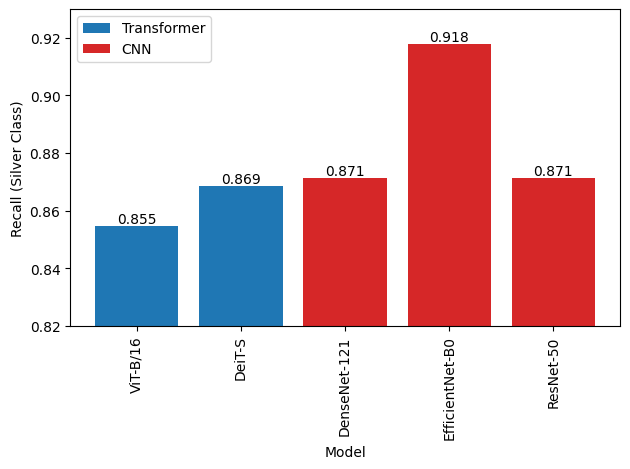

In [ ]:
plt.rcParams.update({
    "font.size": 10,
    "font.family": "sans-serif"
})

models = ["ViT-B/16", "DeiT-S", "DenseNet-121", "EfficientNet-B0", "ResNet-50"]

# ✅ Recall (Class 1: silver) at BEST thresholds
recall_scores = [0.8548, 0.8685, 0.8712, 0.9178, 0.8712]

colors = [
    "#1f77b4", "#1f77b4",  # Transformers
    "#d62728", "#d62728", "#d62728"  # CNNs
]

plt.figure()

plt.bar(models, recall_scores, color=colors)

plt.xlabel("Model")
plt.ylabel("Recall (Silver Class)")

plt.xticks(rotation=90)

# 🔥 Zoom for clarity
plt.ylim(0.82, 0.93)

# Add values
for i, v in enumerate(recall_scores):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center')

legend_elements = [
    Patch(facecolor="#1f77b4", label="Transformer"),
    Patch(facecolor="#d62728", label="CNN")
]

plt.legend(handles=legend_elements)

plt.tight_layout()

# ✅ Save for paper
plt.savefig("recall_best_threshold.png", dpi=300, bbox_inches='tight')

plt.show()

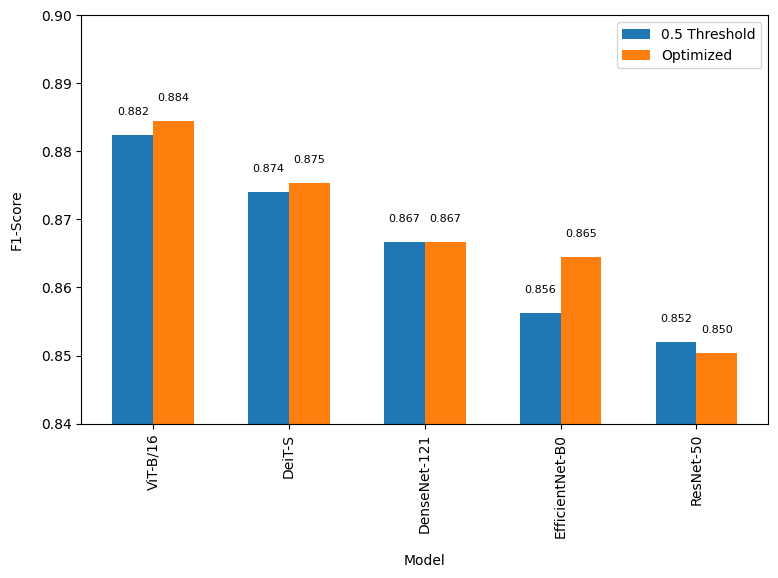

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 10,
    "font.family": "sans-serif"
})

models = ["ViT-B/16", "DeiT-S", "DenseNet-121", "EfficientNet-B0", "ResNet-50"]

# F1 @ threshold = 0.5
f1_05 = [0.8824, 0.8742, 0.8665, 0.8564, 0.8520]

# F1 @ optimized threshold
f1_opt = [0.8844, 0.8835, 0.8665, 0.8645, 0.8503]

x = np.arange(len(models))
width = 0.30

# Same size as recall graph
plt.figure(figsize=(8, 6))

# Bars
bars1 = plt.bar(x - width/2, f1_05, width,
                label="0.5 Threshold", color="#1f77b4")

bars2 = plt.bar(x + width/2, f1_opt, width,
                label="Optimized", color="#ff7f0e")

# Labels
plt.xlabel("Model", labelpad=12)
plt.ylabel("F1-Score", labelpad=12)

plt.xticks(x, models, rotation=90)

# Match zoom style
plt.ylim(0.84, 0.90)

# ✅ Correct label spacing (matches recall graph)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.003,   # ← fixed spacing
            f"{height:.3f}",
            ha='center',
            fontsize=8
        )

# Legend
plt.legend()

# Layout
plt.tight_layout(pad=1.5)

# Save
plt.savefig("f1_combined.png", dpi=300, bbox_inches='tight')

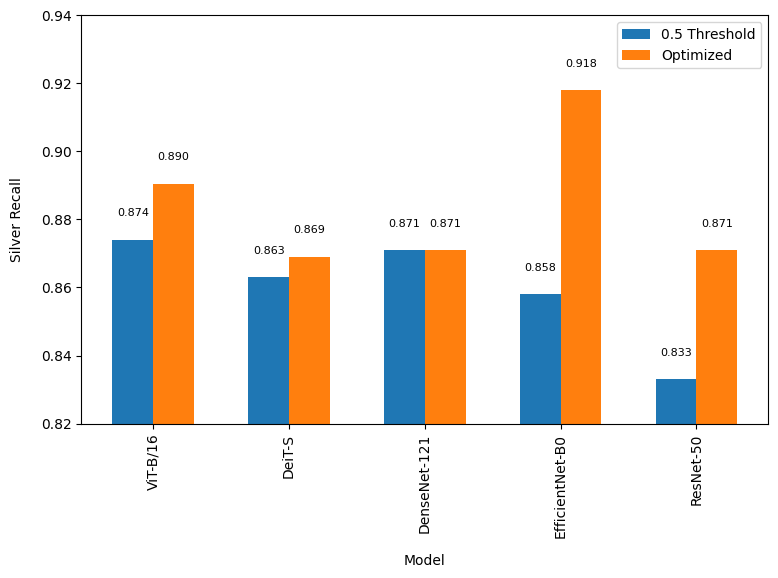

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 10,
    "font.family": "sans-serif"
})

models = ["ViT-B/16", "DeiT-S", "DenseNet-121", "EfficientNet-B0", "ResNet-50"]

# Recall @ 0.5
recall_05 = [0.8740, 0.863, 0.871, 0.858, 0.833]

# Recall @ optimized
recall_opt = [0.8904, 0.869, 0.871, 0.918, 0.871]

x = np.arange(len(models))
width = 0.30

# Taller figure
plt.figure(figsize=(8, 6))

# Bars
bars1 = plt.bar(x - width/2, recall_05, width,
                label="0.5 Threshold", color="#1f77b4")

bars2 = plt.bar(x + width/2, recall_opt, width,
                label="Optimized", color="#ff7f0e")

# Labels
plt.xlabel("Model", labelpad=12)
plt.ylabel("Silver Recall", labelpad=12)

plt.xticks(x, models, rotation=90)

# Headroom
plt.ylim(0.82, 0.94)

# Value labels (extra spacing to avoid overlap)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.007,   # slightly higher for clarity
            f"{height:.3f}",
            ha='center',
            fontsize=8
        )

# Legend
plt.legend()

# Layout
plt.tight_layout(pad=1.5)

# Save
plt.savefig("recall_combined.png", dpi=300, bbox_inches='tight')

plt.show()